c:\Users\Akshunn Garg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 125s 299ms/step - accuracy: 0.7881 - loss: 0.4406 - val_accuracy: 0.8624 - val_loss: 0.3192
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 24105s 62s/step - accuracy: 0.9033 - loss: 0.2464 - val_accuracy: 0.8674 - val_loss: 0.3079
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 381s 974ms/step - accuracy: 0.9356 - loss: 0.1719 - val_accuracy: 0.8686 - val_loss: 0.3296
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 382s 978ms/step - accuracy: 0.9525 - loss: 0.1306 - val_accuracy: 0.8593 - val_loss: 0.3842
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 250s 485ms/step - accuracy: 0.9693 - loss: 0.0884 - val_accuracy: 0.8496 - val_loss: 0.4179
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.8496 - loss: 0.4179
Test Accuracy: 0.8496000170707703


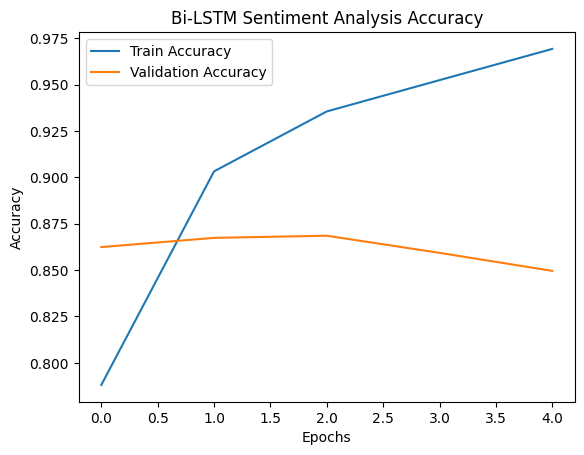

In [1]:
# Bi-Directional LSTM for Sentiment Analysis on IMDB Dataset

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Parameters
vocab_size = 10000
max_length = 200

# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# Build Bi-LSTM model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test)
)

# Evaluate model
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

# Plot training performance
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Bi-LSTM Sentiment Analysis Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
